<a href="https://colab.research.google.com/github/rizbuy/Analisis-Data-Dicoding/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Rizky_Maulana_Ayub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [228]:
#Type your code here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [229]:
# Load data
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

In [230]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [231]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [232]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

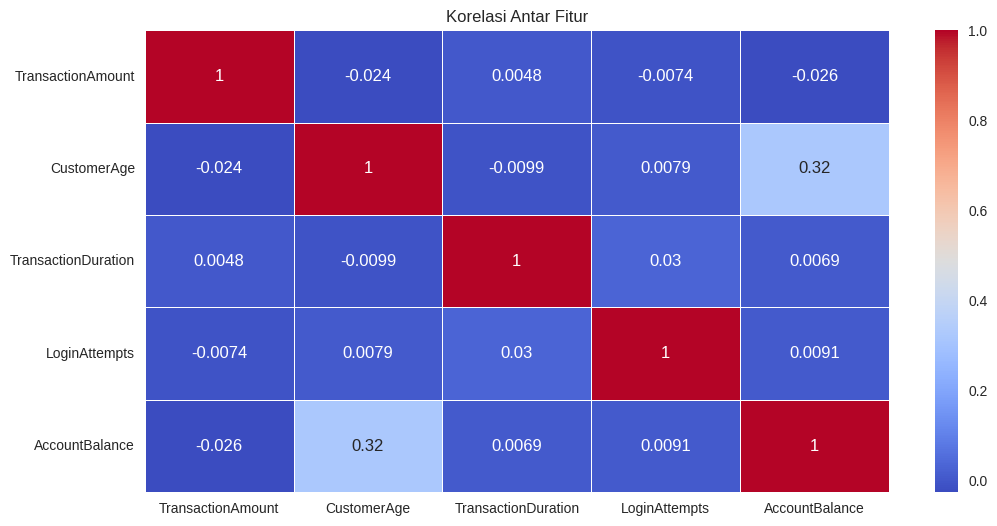

In [233]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

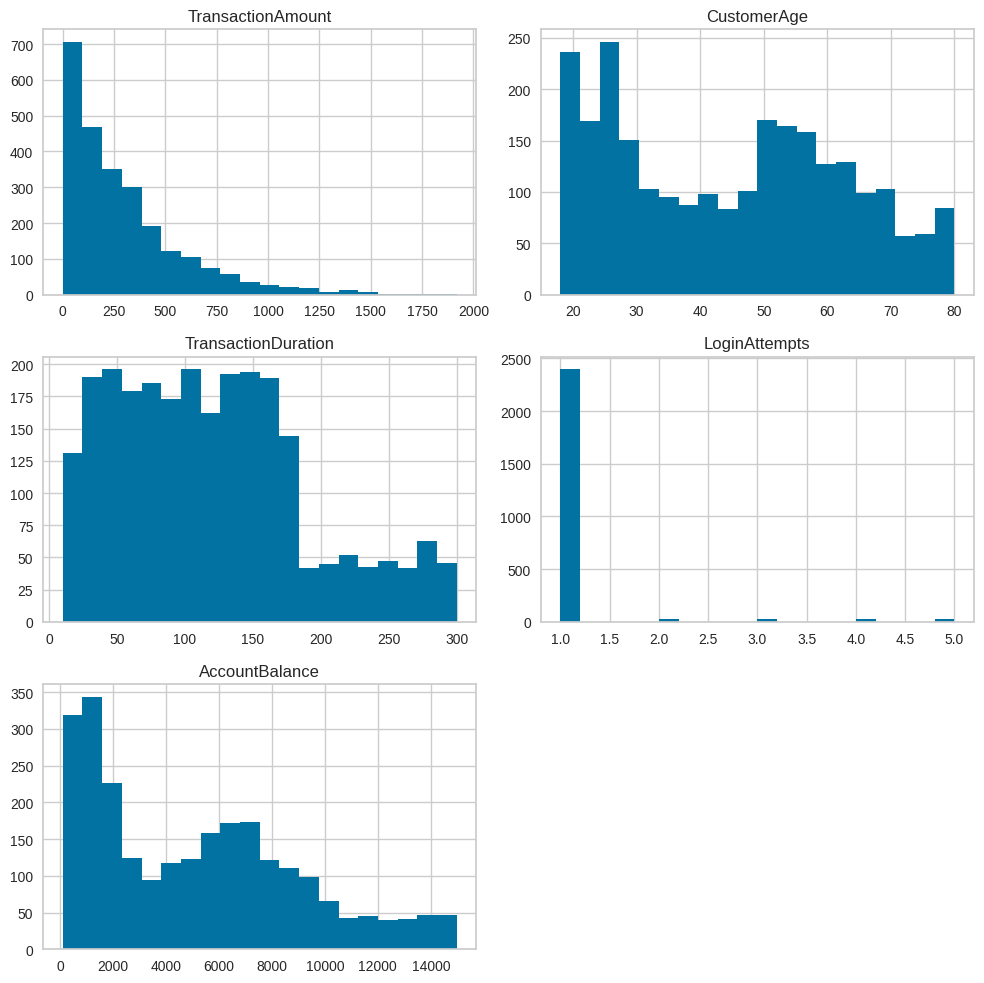

In [234]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
df[numerical_cols].hist(figsize=(10, 10), bins=20)
plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

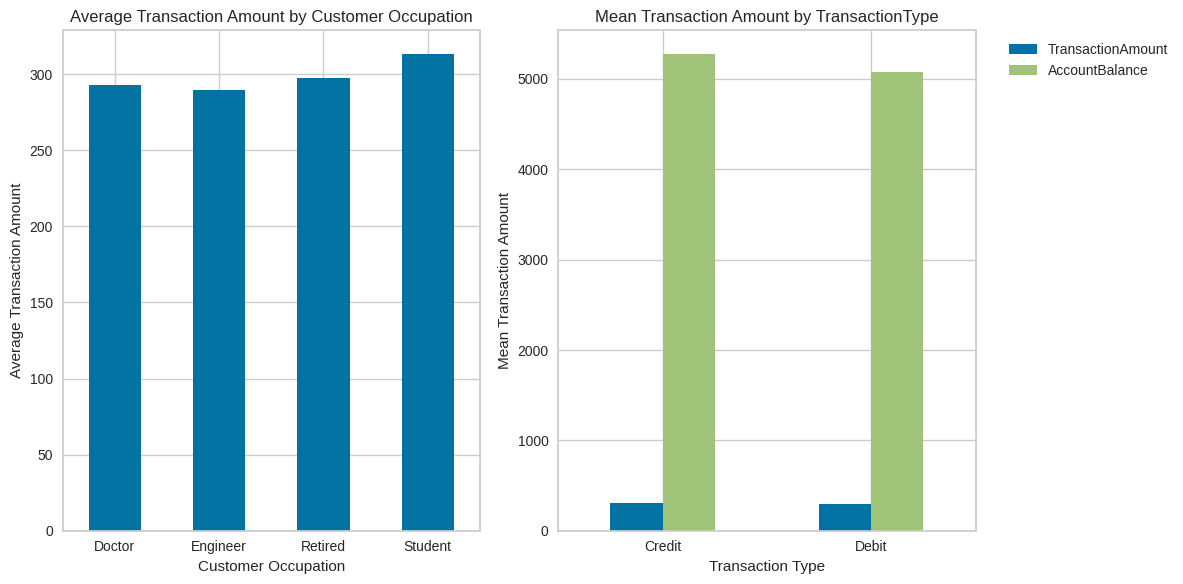

In [235]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
df.groupby('CustomerOccupation')['TransactionAmount'].mean().plot(kind='bar', ax=ax1)
ax1.set_xlabel('Customer Occupation')
ax1.set_ylabel('Average Transaction Amount')
ax1.set_title('Average Transaction Amount by Customer Occupation')
ax1.tick_params(axis='x', rotation=0)
df.groupby('TransactionType')[['TransactionAmount','AccountBalance']].mean().plot(kind='bar', ax=ax2)
ax2.set_xlabel('Transaction Type')
ax2.set_ylabel('Mean Transaction Amount')
ax2.set_title('Mean Transaction Amount by TransactionType')
ax2.tick_params(axis='x', rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [236]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [237]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [238]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 8:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 8:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 8:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 8:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 8:06:39


In [239]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(['TransactionID', 'AccountID', 'DeviceID', 'IP Address','MerchantID'], axis=1)

In [240]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.
encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    encoders[col] = encoder
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163
4,-0.972736,1939,0,1,2,NaN,3,1.121495,-0.204629,0.594263,16


In [241]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'PreviousTransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'TransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [242]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
df.isnull().sum()

,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [243]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates(inplace=True)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [244]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[~((df < (lower_bound)) | (df > (upper_bound))).any(axis=1)]
df.describe()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
count,1743.000000,1743.000000,1743.0,1743.000000,1743.000000,1743.000000,1743.000000,1743.000000,1.743000e+03,1743.000000,1743.00000
mean,-0.164284,1241.395295,1.0,21.288583,0.925990,-0.018740,1.529547,-0.006307,-2.046294e-01,-0.005291,181.78887
std,0.725926,729.014753,0.0,12.375159,0.841467,0.989575,1.150108,1.002039,4.580984e-15,0.980880,103.60451
min,-1.017881,0.000000,1.0,0.000000,0.000000,-1.495947,0.000000,-1.561745,-2.046294e-01,-1.286100,0.00000
25%,-0.753396,614.500000,1.0,11.000000,0.000000,-0.991288,1.000000,-0.805299,-2.046294e-01,-0.926091,94.00000
50%,-0.353512,1233.000000,1.0,21.000000,1.000000,-0.038043,2.000000,-0.105944,-2.046294e-01,-0.097334,182.00000
75%,0.229175,1872.500000,1.0,32.000000,2.000000,0.746983,3.000000,0.607683,-2.046294e-01,0.637865,271.00000
max,2.050618,2485.000000,1.0,43.000000,3.000000,1.980594,4.000000,2.577295,-2.046294e-01,2.531190,360.00000


In [245]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.
df_raw = df.copy()

# Kembalikan kolom numerik ke skala asli
df_raw[numerical_cols] = scaler.inverse_transform(df_raw[numerical_cols])

# Buat kolom age_group
bins = [18, 27, 42, 57, 80]
labels = ['18-27: Gen Z', '28-42: Milenial', '43-57: Gen X', '58-80: Lansia']
df['age_group'] = pd.cut(
    df_raw['CustomerAge'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# Buat rasio balance terhadap transaksi
df['balance_to_transaction'] = (
    df_raw['AccountBalance'] / (df_raw['TransactionAmount'] + 1)
).round(2)

# Kategorikan kesehatan finansial berdasarkan kuartil
df['financial_health'] = pd.qcut(
    df['balance_to_transaction'],
    q=4,
    labels=['Kritis', 'Stabil', 'Sehat', 'Sangat Sehat'],
    duplicates='drop'  # hindari error jika banyak nilai sama
)

# Encode kolom kategorikal (termasuk yang baru dibuat)
categorical_updated = df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}
for col in categorical_updated:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
scaler_updated = StandardScaler()
df['balance_to_transaction'] = scaler_updated.fit_transform(df[['balance_to_transaction']])
df.tail()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,age_group,balance_to_transaction,financial_health
2506,-0.703067,692,1,30,1,0.859129,1,-0.377123,-0.204629,0.468039,163,3,-0.056147,1
2508,-0.157840,564,1,40,1,0.186250,0,0.821772,-0.204629,-1.246713,318,2,-0.263518,0
2509,-0.920781,1531,1,36,1,0.634836,2,0.379322,-0.204629,-0.444044,136,2,0.056227,1
2510,-0.382263,376,1,10,2,-1.215581,3,-1.433292,-0.204629,-0.856135,358,0,-0.239528,3
2524,-0.224308,2461,1,29,0,-0.430555,1,-0.976570,-0.204629,0.404504,174,1,-0.185277,2


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [246]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,age_group,balance_to_transaction,financial_health
count,1743.000000,1743.000000,1743.0,1743.000000,1743.000000,1743.000000,1743.000000,1743.000000,1.743000e+03,1743.000000,1743.00000,1743.000000,1.743000e+03,1743.000000
mean,-0.164284,1241.395295,1.0,21.288583,0.925990,-0.018740,1.529547,-0.006307,-2.046294e-01,-0.005291,181.78887,1.623637,-1.426793e-17,1.499713
std,0.725926,729.014753,0.0,12.375159,0.841467,0.989575,1.150108,1.002039,4.580984e-15,0.980880,103.60451,1.140806,1.000287e+00,1.118611
min,-1.017881,0.000000,1.0,0.000000,0.000000,-1.495947,0.000000,-1.561745,-2.046294e-01,-1.286100,0.00000,0.000000,-2.660043e-01,0.000000
25%,-0.753396,614.500000,1.0,11.000000,0.000000,-0.991288,1.000000,-0.805299,-2.046294e-01,-0.926091,94.00000,1.000000,-2.441765e-01,0.500000
50%,-0.353512,1233.000000,1.0,21.000000,1.000000,-0.038043,2.000000,-0.105944,-2.046294e-01,-0.097334,182.00000,2.000000,-2.064125e-01,1.000000
75%,0.229175,1872.500000,1.0,32.000000,2.000000,0.746983,3.000000,0.607683,-2.046294e-01,0.637865,271.00000,3.000000,-1.022469e-01,2.500000
max,2.050618,2485.000000,1.0,43.000000,3.000000,1.980594,4.000000,2.577295,-2.046294e-01,2.531190,360.00000,4.000000,1.810517e+01,3.000000


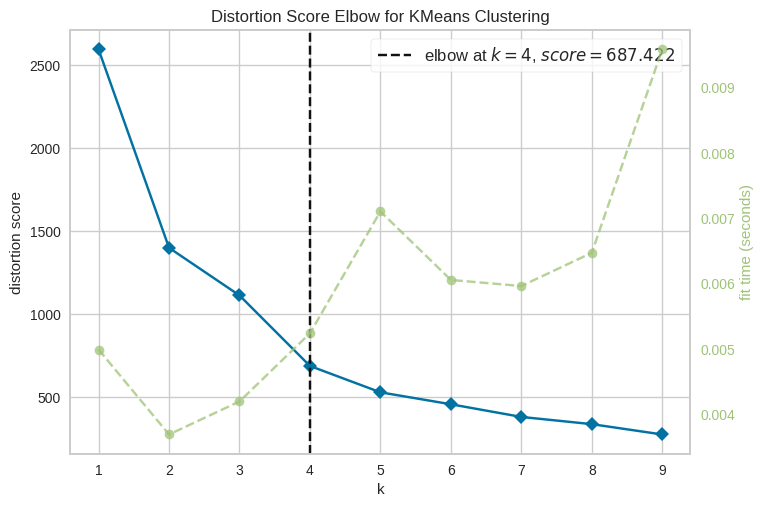

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [247]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
features = ['TransactionAmount', 'AccountBalance']
X = df[features]
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))
visualizer.fit(X)
visualizer.show()

In [248]:
# Menggunakan algoritma K-Means Clustering
k = 3
model = KMeans(n_clusters=k, random_state=0)
model.fit(X)
df['Cluster'] = model.labels_

Jalankan cell code ini untuk menyimpan model kamu.

In [249]:
# Menyimpan model menggunakan joblib
import joblib
joblib.dump(model, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [250]:
# Menghitung dan menampilkan nilai Silhouette Score.
silhouette_avg = silhouette_score(X, model.labels_)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.42997890890515994


Cluster 1:
Mean Transaction Amount: -0.30268494419291353
Mean Customer Age: 1.0160254085861578

Cluster 2:
Mean Transaction Amount: -0.5213411741575145
Mean Customer Age: -0.7089439298115894

Cluster 3:
Mean Transaction Amount: 0.9887353203000413
Mean Customer Age: -0.41505656575197614



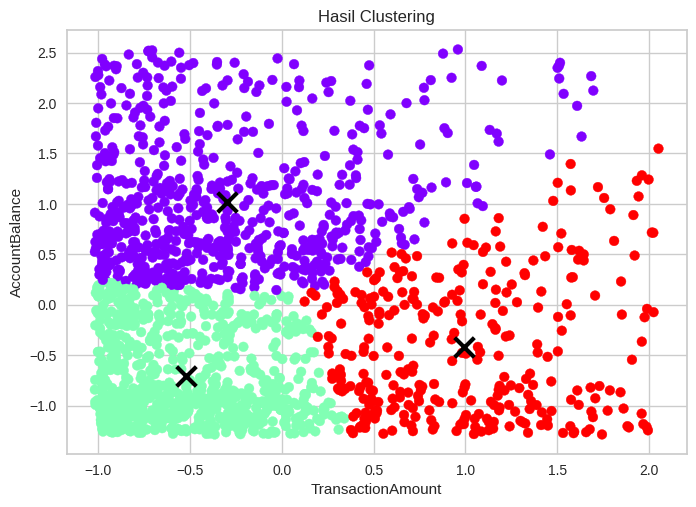

In [251]:
# Membuat visualisasi hasil clustering
def analyzer_cluster (X, labels, k):
    for cluster_id in range(k):
        cluster_data = X[labels == cluster_id]
        mean_transaction_amount = cluster_data['TransactionAmount'].mean()
        mean_customer_age = cluster_data['AccountBalance'].mean()
        print(f"Cluster {cluster_id + 1}:")
        print(f"Mean Transaction Amount: {mean_transaction_amount}")
        print(f"Mean Customer Age: {mean_customer_age}")
        print()
analyzer_cluster(X, model.labels_, k)

centroids = model.cluster_centers_
plt.scatter(X['TransactionAmount'], X['AccountBalance'], c=model.labels_, cmap='rainbow')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, linewidths=3, color='black')
plt.xlabel('TransactionAmount')
plt.ylabel('AccountBalance')
plt.title('Hasil Clustering')
plt.show()


(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [252]:
# Membangun model menggunakan PCA.
pca =PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_<numbers>
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
model_pca = KMeans(n_clusters=3, random_state=0)
model_pca.fit(df_pca)
silhouette_pca = silhouette_score(df_pca, model_pca.labels_)
print(f"Silhouette Score (PCA): {silhouette_pca}")
df_pca['cluster'] = model_pca.labels_
df_pca.describe()

Silhouette Score (PCA): 0.42997890890515994


,PCA1,PCA2,cluster
count,1.743000e+03,1.743000e+03,1743.000000
mean,1.019138e-17,-3.872723e-17,0.804934
std,9.809287e-01,7.258608e-01,0.721841
min,-1.308566e+00,-8.658417e-01,0.000000
25%,-9.167699e-01,-5.890331e-01,0.000000
50%,-8.374783e-02,-1.895689e-01,1.000000
75%,6.446654e-01,3.929874e-01,1.000000
max,2.535158e+00,2.237577e+00,2.000000


In [253]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(model_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [254]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.
numerical_scaled = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'balance_to_transaction', 'Cluster']
df.groupby('Cluster')[numerical_scaled].agg(['mean', 'min', 'max'])

TransactionAmount                     CustomerAge                      \
                     mean       min       max        mean       min       max   
Cluster                                                                         
0               -0.302685 -1.017676  1.695827    0.277828 -1.495947  1.980594   
1               -0.521341 -1.017881  0.340051   -0.229450 -1.495947  1.980594   
2                0.988735  0.124288  2.050618   -0.122241 -1.495947  1.980594   

        TransactionDuration                     LoginAttempts  ...            \
                       mean       min       max          mean  ...       max   
Cluster                                                        ...             
0                 -0.063127 -1.561745  2.577295     -0.204629  ... -0.204629   
1                  0.014138 -1.533199  2.563023     -0.204629  ... -0.204629   
2                  0.061860 -1.561745  2.463115     -0.204629  ... -0.204629   

        AccountBalance                     balance_to_transaction            \
                  mean       min       max                   mean       min   
Cluster                                                                       
0             1.016025  0.146272  2.531190               0.238371 -0.225570   
1            -0.708944 -1.286100  0.216902              -0.101044 -0.265128   
2            -0.415057 -1.285856  1.548112              -0.248918 -0.266004   

                   Cluster          
               max    mean min max  
Cluster                             
0        18.105172     0.0   0   0  
1         5.864522     1.0   1   1  
2        -0.220823     2.0   2   2  

[3 rows x 21 columns]

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1.   **Cluster 1: Pelanggan "Normal" dengan Transaksi & Usia Moderat**
  - **Rata-rata (mean) TransactionAmount :** -0.303/209.22
  - **Rata-rata (mean) AccountBalance:** 1.016/ 9073.89
*   **Analisis**: Cluster ini adalah Cluster mayoritas atau "normal". Mereka cenderung memiliki aktivitas yang seimbang. Keuangan & Risiko: Memiliki skor AccountBalance (1.016) yang paling tinggi (di atas rata-rata global) di antara semua Cluster. Rasio balance_to_transaction juga sangat tinggi. Sesuai dengan Mode financial_health yang 'Sangat Sehat'. Transaksi: Skor TransactionAmount (-0.303) dan durasinya moderat (sedikit di atas rata-rata global). Usia: Usia rata-rata mendekati 50 tahun, tetapi Mode usia mereka adalah Lansia (58-80). Aktivitas & Logistik: Transaksi sering terjadi melalui Debit di lokasi seperti Fort Worth/Charlotte. Kesimpulan: Cluster ini didominasi oleh Pelanggan Senior dengan stabilitas finansial tinggi, ditunjukkan oleh saldo akun yang jauh di atas rata-rata, yang berarti risiko mereka sangat rendah.

2. **Cluster 2: Pelanggan Berisiko & Kesehatan Finansial Kritis (Nilai Transaksi Rendah)**:
  - **Rata-rata (mean) TransactionAmount :** -0.521
  /145.33
  - **Rata-rata (mean) AccountBalance:**  -0.708/2556.54
  - **Analisis:** Cluster ini menunjukkan karakteristik risiko tinggi dan kesehatan finansial yang buruk. Keuangan: Memiliki skor AccountBalance (-0.708) dan TransactionAmount (-0.521) yang sangat rendah (jauh di bawah rata-rata global), menunjukkan nilai rata-rata terendah pada keduanya. Rasio Saldo-ke-Transaksi Rata-rata terendah kedua (≈ 58.51). Mode financial_health mereka adalah Kritis. Demografi: Mode usia mereka adalah Gen Z (18-27), yang mungkin memiliki pendapatan dan saldo yang lebih kecil. Aktivitas: Transaksi (skor -0.521) meskipun bernilai kecil, membebani saldo (skor -0.708) mereka yang sudah kecil. Pola transaksi (Debit, ATM) konsisten dengan aktivitas pengeluaran/penarikan cepat. Kesimpulan: Cluster ini adalah Cluster Berisiko/Perhatian (Alert). Nilai transaksi dan saldo yang jauh di bawah rata-rata (negatif) menunjukkan masalah likuiditas ekstrem pada demografi muda.
3.   **Cluster** 3: **Cluster "Anomali Jangka Pendek" atau "High-Value Transfer"**
  - **Rata-rata (mean) TransactionAmount :** 0.990/586.33
  - **Rata-rata (mean) AccountBalance:** -0.415/3495.88
*   **Analisis**:Cluster ini memiliki skor TransactionAmount (0.990) tertinggi, tetapi skor AccountBalance (-0.415) di bawah rata-rata global, menunjukkan pengurasan dana yang cepat relatif terhadap saldo. Keuangan & Risiko: Memiliki skor Nilai Transaksi (0.990) yang paling tinggi dan juga rasio balance_to_transaction yang paling rendah (6.17). Mode financial_health adalah 'Kritis'. Kombinasi ini sangat mengkhawatirkan karena transaksi besar terjadi pada pelanggan dengan saldo di bawah rata-rata. Transaksi: Durasi transaksi hampir sama dengan Cluster 1. Kolom Target di bagian bawah menunjukkan nilai ≈6501 pada PreviousTransactionDate yang mungkin merupakan nilai encoded tinggi, dan nilai Target=2 untuk TransactionDuration memiliki min=2 dan max=2. Usia: Usia rata-rata 42 tahun. Mode usianya bimodal (Gen Z & Lansia), mengindikasikan bahwa Cluster ini tidak terikat pada satu demografi usia. Aktivitas & Logistik: Mode transaksi adalah Debit di Los Angeles/San Jose (lokasi yang sama sekali berbeda dari Cluster 1) dengan Channel ATM. Kesimpulan: Cluster ini adalah Cluster Fraud atau Anomali Nilai Tinggi. Ditandai dengan transaksi pengeluaran high-value (skor 0.990) yang sangat agresif yang dengan cepat menghabiskan saldo di bawah rata-rata (skor -0.521), menjadikannya risiko tertinggi.




# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [255]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df = df.rename(columns={'Cluster': 'Target'})

In [256]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [257]:
# inverse dataset ke rentang normal untuk numerikal
df[numerical_cols] = scaler.inverse_transform(df[numerical_cols])
df['balance_to_transaction'] = scaler_updated.inverse_transform(df[['balance_to_transaction']])
# tampilkan dataset yang sudah di-inverse
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 0 to 2524
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        1743 non-null   float64
 1   PreviousTransactionDate  1743 non-null   int64  
 2   TransactionType          1743 non-null   int64  
 3   Location                 1743 non-null   int64  
 4   Channel                  1743 non-null   int64  
 5   CustomerAge              1743 non-null   float64
 6   CustomerOccupation       1743 non-null   int64  
 7   TransactionDuration      1743 non-null   float64
 8   LoginAttempts            1743 non-null   float64
 9   AccountBalance           1743 non-null   float64
 10  TransactionDate          1743 non-null   int64  
 11  age_group                1743 non-null   int64  
 12  balance_to_transaction   1743 non-null   float64
 13  financial_health         1743 non-null   int64  
 14  Target                   1743

In [258]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
all_encoders = {}
all_encoders.update(encoders)
all_encoders.update(label_encoders)

all_encoded_cols = list(all_encoders.keys())

for col in all_encoded_cols:
    if col in df.columns:
        df[col] = all_encoders[col].inverse_transform(df[col].astype(int))

# tampilkan dataset yang sudah di-inverse
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 0 to 2524
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        1743 non-null   float64
 1   PreviousTransactionDate  1743 non-null   object 
 2   TransactionType          1743 non-null   object 
 3   Location                 1743 non-null   object 
 4   Channel                  1743 non-null   object 
 5   CustomerAge              1743 non-null   float64
 6   CustomerOccupation       1743 non-null   object 
 7   TransactionDuration      1743 non-null   float64
 8   LoginAttempts            1743 non-null   float64
 9   AccountBalance           1743 non-null   float64
 10  TransactionDate          1743 non-null   object 
 11  age_group                1743 non-null   object 
 12  balance_to_transaction   1743 non-null   float64
 13  financial_health         1743 non-null   object 
 14  Target                   1743

In [259]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.numerical_cols_inverse = df.select_dtypes(np.number).columns.to_list()
numerical_cols_inverse = df.select_dtypes(np.number).columns.to_list()
categorical_cols_inverse = df.select_dtypes(include=['object', 'category']).columns.to_list()

print(f'Numerical Columns: {numerical_cols_inverse}')
print(f'Categorical Columns: {categorical_cols_inverse}')

agg_numeric = df.groupby('Target')[numerical_cols_inverse].agg(['mean', 'min', 'max'])
categorical_agg = df.groupby('Target')[categorical_cols_inverse].agg(pd.Series.mode)

print(f'Numerical Aggregation:\n{agg_numeric}')
print(f'Categorical Aggregation:\n{categorical_agg}')

Numerical Columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'balance_to_transaction', 'Target']
Categorical Columns: ['PreviousTransactionDate', 'TransactionType', 'Location', 'Channel', 'CustomerOccupation', 'TransactionDate', 'age_group', 'financial_health']
Numerical Aggregation:
       TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             209.220350    0.32  793.13   49.633181  18.0  80.0   
1             145.335085    0.26  397.01   40.586476  18.0  80.0   
2             586.537413  333.97  896.79   42.498423  18.0  80.0   

       TransactionDuration              LoginAttempts  ...       \
                      mean   min    max          mean  ...  max   
Target                                                 ...        
0               115.000000  10.0  300.0           1.

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1.   **Cluster 1: Pelanggan "Normal" dengan Transaksi & Usia Moderat**
  - **Rata-rata (mean) TransactionAmount :** -0.302/289.22
  - **Rata-rata (mean) AccountBalance:** 1.016/ 9073.89
*   **Analisis**: Cluster ini adalah Cluster mayoritas atau "normal". Mereka cenderung memiliki aktivitas yang seimbang. Keuangan & Risiko: Memiliki Keseimbangan Akun (9K) yang paling tinggi di antara semua Cluster. Rasio balance_to_transaction juga sangat tinggi. Sesuai dengan Mode financial_health yang 'Sangat Sehat'. Transaksi: Jumlah transaksi ($289) dan durasinya moderat.Usia: Usia rata-rata mendekati 50 tahun, tetapi Mode usia mereka adalah Lansia (58-80). Aktivitas & Logistik: Transaksi sering terjadi melalui Debit di lokasi seperti Fort Worth/Charlotte. Kesimpulan: Cluster ini didominasi oleh Pelanggan Senior dengan stabilitas finansial tinggi dan saldo akun yang besar, yang berarti risiko mereka sangat rendah.


2. **Cluster 2: Pelanggan Berisiko & Kesehatan Finansial Kritis (Nilai Transaksi Rendah)**:
  - **Rata-rata (mean) TransactionAmount :** -0.521
  /145.33
  - **Rata-rata (mean) AccountBalance:**  -0.708/2556.54
  - **Analisis:** Cluster ini menunjukkan karakteristik risiko tinggi dan kesehatan finansial yang buruk. Keuangan: Memiliki Saldo Akun Rata-rata terendah (≈2.556) dan Rasio Saldo-ke-Transaksi Rata-rata terendah kedua (≈58.51). Mode financial_health mereka adalah Kritis. Demografi: Mode usia mereka adalah Gen Z (18-27), yang mungkin memiliki pendapatan dan saldo yang lebih kecil. Aktivitas: Meskipun nilai transaksi rata-rata mereka rendah (≈145), transaksi ini membebani saldo mereka yang sudah kecil. Pola transaksi (Debit, ATM) konsisten dengan aktivitas pengeluaran/penarikan cepat. Kesimpulan: Cluster ini adalah Cluster Berisiko/Perhatian (Alert). Transaksi, meskipun bernilai kecil, berpotensi menunjukkan fraud kecil atau masalah likuiditas yang ekstrem pada demografi muda.
3.   **Cluster** 3: **Cluster "Anomali Jangka Pendek" atau "High-Value Transfer"**
  - **Rata-rata (mean) TransactionAmount :** 0.990/586.33
  - **Rata-rata (mean) AccountBalance:** -0.521/3495.88
*   **Analisis**: Cluster ini memiliki nilai transaksi tertinggi tetapi rasio balance-to-transaction terendah, menunjukkan pengurasan dana yang cepat relatif terhadap saldo.Keuangan & Risiko: Memiliki Nilai Transaksi ($586) yang paling tinggi dan juga rasio balance_to_transaction yang paling rendah (6.17). Mode financial_health adalah 'Kritis'. Kombinasi ini sangat mengkhawatirkan karena transaksi besar terjadi pada pelanggan dengan rasio dana-terhadap-transaksi yang kecil (artinya, dananya cepat terkuras).Transaksi: Durasi transaksi hampir sama dengan Cluster 1. Kolom Target di bagian bawah menunjukkan nilai ≈6501 pada PreviousTransactionDate yang mungkin merupakan nilai encoded tinggi, dan nilai Target=2 untuk TransactionDuration memiliki min=2 dan max=2. Usia: Usia rata-rata 42 tahun. Mode usianya bimodal (Gen Z & Lansia), mengindikasikan bahwa Cluster ini tidak terikat pada satu demografi usia. Aktivitas & Logistik: Mode transaksi adalah Debit di Los Angeles/San Jose (lokasi yang sama sekali berbeda dari Cluster 1) dengan Channel ATM. Kesimpulan: Cluster ini adalah Cluster Fraud atau Anomali Nilai Tinggi. Ditandai dengan transaksi pengeluaran high-value yang sangat agresif yang dengan cepat menghabiskan saldo, menjadikannya risiko tertinggi.




(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [260]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df.head()

,TransactionAmount,PreviousTransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,age_group,balance_to_transaction,financial_health,Target
0,14.09,2023-04-11 16:29:14,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08,58-80: Lansia,338.78,Sangat Sehat,1
1,376.24,2023-06-27 16:44:19,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35,58-80: Lansia,36.47,Sehat,0
2,126.29,2023-07-10 18:16:08,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04,18-27: Gen Z,8.82,Stabil,1
3,184.50,2023-05-05 16:32:11,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06,18-27: Gen Z,46.19,Sehat,0
5,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 8:06:36,18-27: Gen Z,8.39,Stabil,1


In [261]:
# Simpan Data
df.to_csv('data_clustering_inverse.csv', index=False)
df.isnull().sum()

,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
Channel,0
CustomerAge,0
CustomerOccupation,0
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


In [262]:
df_inverse = pd.read_csv('data_clustering_inverse.csv')
df_inverse.isnull().sum()

,0
TransactionAmount,0
PreviousTransactionDate,17
TransactionType,0
Location,21
Channel,18
CustomerAge,0
CustomerOccupation,14
TransactionDuration,0
LoginAttempts,0
AccountBalance,0


End of Code.